# import library and dataset

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("cardio_train.csv", sep=';')


# 2. Remove duplicate rows

In [119]:
df = df.drop(columns=['id'])

df.drop_duplicates(inplace=True)
print(df.shape)



(69976, 12)


## 1. Convert age from days to years


In [120]:

df['age_years'] = (df['age'] / 365).astype(int)

print(df[['age','age_years']].head())
df.drop(columns=['age'], inplace=True)


     age  age_years
0  18393         50
1  20228         55
2  18857         51
3  17623         48
4  17474         47


# 3. if Nan Numerical columns → Fill with mean
# Categorical columns → Fill with mode

In [121]:
# Numerical
df.fillna(df.mean(numeric_only=True), inplace=True)

# Categorical
for col in df.select_dtypes(include='object'):
        df[col].fillna(df[col].mode()[0], inplace=True)
df

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,156,85.0,140,90,3,1,0,0,1,1,55
2,1,165,64.0,130,70,3,1,0,0,0,1,51
3,2,169,82.0,150,100,1,1,0,0,1,1,48
4,1,156,56.0,100,60,1,1,0,0,0,0,47
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,168,76.0,120,80,1,1,1,0,1,0,52
69996,1,158,126.0,140,90,2,2,0,0,1,1,61
69997,2,183,105.0,180,90,3,1,0,1,0,1,52
69998,1,163,72.0,135,80,1,2,0,0,0,1,61


# Check NaNs after replacement

In [122]:
df.isna().sum()

gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64

# 4. Identify & Handle OutliersUsing IQR Method
outliers replace with standard scaler

In [123]:
# Q1 = df.quantile(0.25)
# Q3 = df.quantile(0.75)
# IQR = Q3 - Q1

# df = df[~((df < (Q1 - 1.5 * IQR)) |
#           (df > (Q3 + 1.5 * IQR))).any(axis=1)]
# df

# Q1 = df.quantile(0.05)
# Q3 = df.quantile(0.90)
# IQR = Q3 - Q1

# df = df[~((df < (Q1 - 0.5 * IQR)) |
#           (df > (Q3 + 0.5 * IQR))).any(axis=1)]
# df

In [124]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.boxplot(data=df[['age_years', 'weight', 'height']])
# plt.title("Outlier Detection using Boxplot")
# plt.show()


# 5. Remove rows where diastolic BP > systolic BP


In [125]:

df1 = df[df['ap_lo'] > df['ap_hi']]
df1

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
228,2,183,98.0,160,1100,1,2,1,0,1,1,47
241,2,157,60.0,160,1000,2,1,0,0,0,1,60
260,1,150,83.0,140,800,1,1,0,0,1,1,49
329,1,176,63.0,160,1000,2,2,0,0,0,1,64
345,1,154,81.0,140,1000,2,1,0,0,1,1,51
...,...,...,...,...,...,...,...,...,...,...,...,...
69771,1,167,81.0,160,1000,1,1,0,0,1,1,63
69872,1,152,56.0,160,1000,1,1,0,0,1,1,59
69878,2,168,95.0,160,1000,1,1,0,0,1,1,58
69885,2,166,78.0,170,1000,1,1,0,0,0,0,61


In [126]:
df = df[df['ap_lo'] <= df['ap_hi']]
df

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,156,85.0,140,90,3,1,0,0,1,1,55
2,1,165,64.0,130,70,3,1,0,0,0,1,51
3,2,169,82.0,150,100,1,1,0,0,1,1,48
4,1,156,56.0,100,60,1,1,0,0,0,0,47
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,168,76.0,120,80,1,1,1,0,1,0,52
69996,1,158,126.0,140,90,2,2,0,0,1,1,61
69997,2,183,105.0,180,90,3,1,0,1,0,1,52
69998,1,163,72.0,135,80,1,2,0,0,0,1,61


# 6. Create a new feature: BMI =  weight/height ratio (Body Mass Index)

In [127]:
df['BMI'] = df['weight'] / ((df['height']/100) ** 2)
print(df[['weight', 'height', 'BMI']].head(10))


   weight  height        BMI
0    62.0     168  21.967120
1    85.0     156  34.927679
2    64.0     165  23.507805
3    82.0     169  28.710479
4    56.0     156  23.011177
5    67.0     151  29.384676
6    93.0     157  37.729725
7    95.0     178  29.983588
8    71.0     158  28.440955
9    68.0     164  25.282570


C:\Users\Creater\AppData\Local\Temp\ipykernel_16584\2279260549.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['BMI'] = df['weight'] / ((df['height']/100) ** 2)


# 8. Create a new feature: pulse pressure

In [128]:
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
print(df[['ap_hi', 'ap_lo', 'pulse_pressure']].head(10))


   ap_hi  ap_lo  pulse_pressure
0    110     80              30
1    140     90              50
2    130     70              60
3    150    100              50
4    100     60              40
5    120     80              40
6    130     80              50
7    130     90              40
8    110     70              40
9    110     60              50


C:\Users\Creater\AppData\Local\Temp\ipykernel_16584\989141914.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']


# 10. replace zero weight or height with median

In [129]:
df['weight'] = df['weight'].replace(0, df['weight'].median())
df['height'] = df['height'].replace(0, df['height'].median())


C:\Users\Creater\AppData\Local\Temp\ipykernel_16584\3318687437.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['weight'] = df['weight'].replace(0, df['weight'].median())
C:\Users\Creater\AppData\Local\Temp\ipykernel_16584\3318687437.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['height'] = df['height'].replace(0, df['height'].median())


## Exploratory Data Analysis (EDA)

# 11. Correlation Heatmap of whole data set

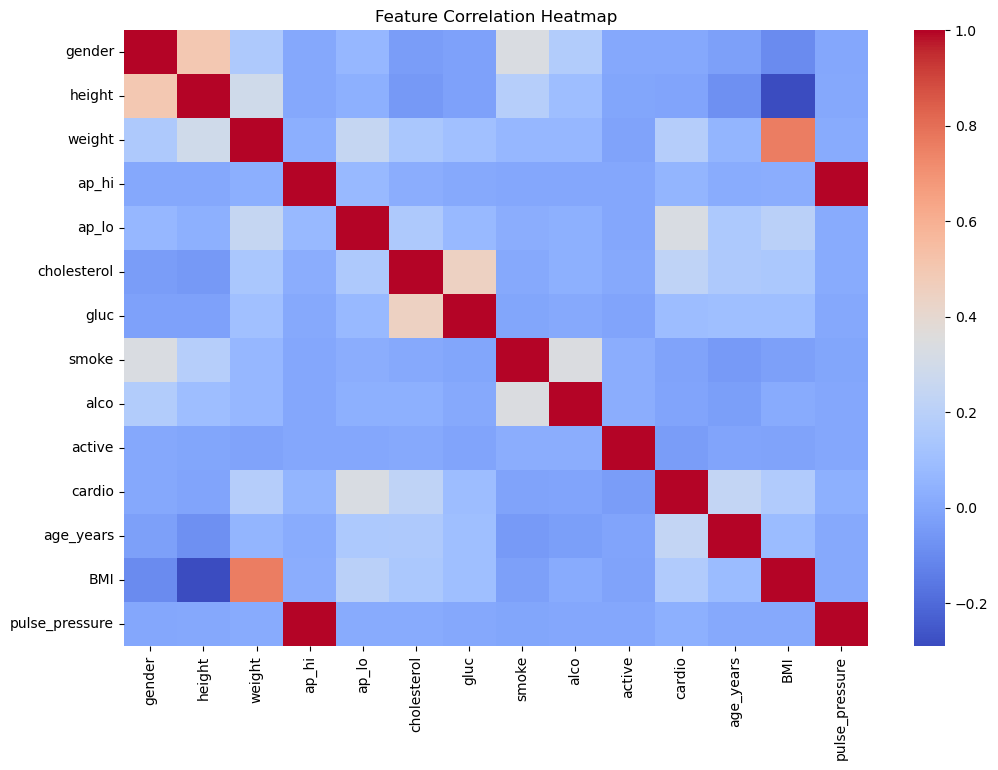

In [130]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


# 12. Outlier Detection using Boxplots

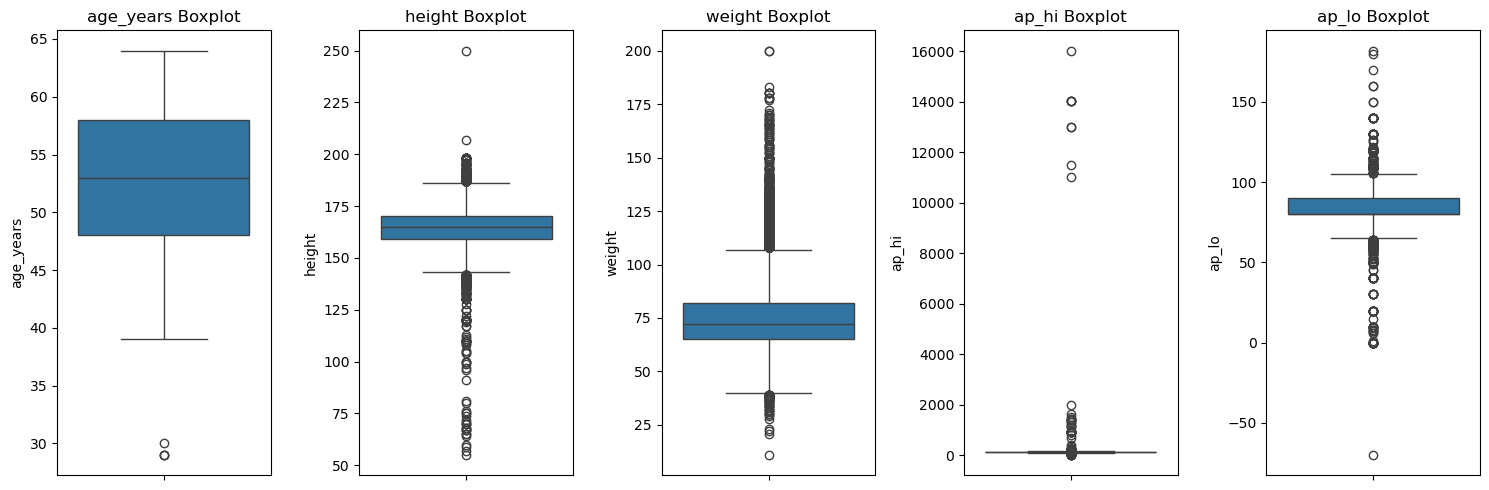

In [131]:
num_cols = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']
plt.figure(figsize=(15,5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, len(num_cols), i)
    sns.boxplot(y=df[col])
    plt.title(f"{col} Boxplot")
plt.tight_layout()
plt.show()


# 13. Feature Distribution with KDE


In [132]:
# plt.figure(figsize=(12,6))
# for i, col in enumerate(num_cols, 1):
#     plt.subplot(2, 3, i)
#     sns.kdeplot(df[col], fill=True, color=np.random.rand(3,))
#     plt.title(f"{col} Distribution")
# plt.tight_layout()
# plt.show()


# 14. Correlation between whole dataset to cardio

In [133]:
target_corr = df.corr()['cardio'].sort_values(ascending=False)
print("Features most correlated with cardio:\n", target_corr)


Features most correlated with cardio:
 cardio            1.000000
ap_lo             0.332502
age_years         0.239080
cholesterol       0.221447
weight            0.179644
BMI               0.163510
gluc              0.089657
ap_hi             0.053189
pulse_pressure    0.032512
gender            0.007069
alco             -0.008681
height           -0.010458
smoke            -0.016368
active           -0.037397
Name: cardio, dtype: float64


# 15. Crosstab Analysis of  Cholesterol vs Cardio

cardio               0          1
cholesterol                      
1            56.446669  43.553331
2            40.360670  59.639330
3            23.730964  76.269036


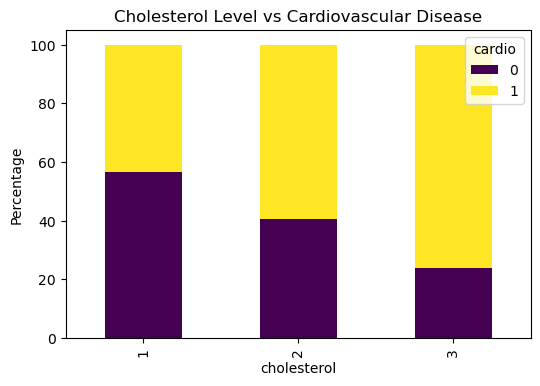

In [134]:
ct = pd.crosstab(df['cholesterol'], df['cardio'], normalize='index')*100
print(ct)

ct.plot(kind='bar', stacked=True, figsize=(6,4), colormap='viridis')
plt.ylabel("Percentage")
plt.title("Cholesterol Level vs Cardiovascular Disease")
plt.show()

# 16. Scatter plot of ap_hi vs ap_lo to visualize BP distribution

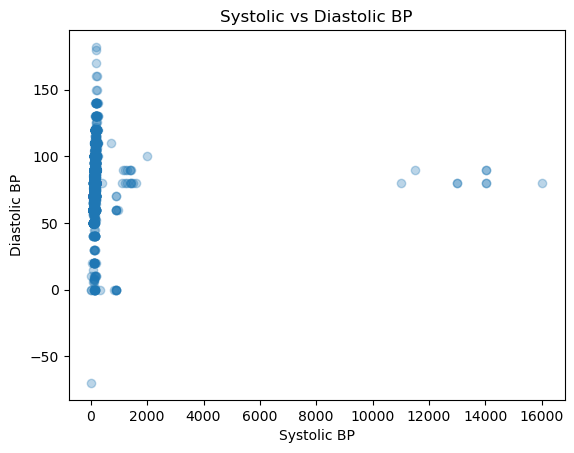

In [135]:
plt.scatter(df['ap_hi'], df['ap_lo'], alpha=0.3)
plt.xlabel("Systolic BP")
plt.ylabel("Diastolic BP")
plt.title("Systolic vs Diastolic BP")
plt.show()


In [136]:
print(df.shape)


(68742, 14)


# Save preprocessed data for modeling:

In [137]:
df.to_csv("cardio_train_cleaned.csv", index=False)


In [1]:
# # Threshold = 0.5 (Default)

# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# df = pd.read_csv('cardio_train_cleaned.csv')

# X = df.drop('cardio', axis=1)
# y = df['cardio']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=2      #random_state is a seed value that controls randomness so your results are reproducible.
# )

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# model = LogisticRegression(max_iter=68742)
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# accuracy = accuracy_score(y_test, y_pred) * 100

# print(f"Accuracy: {accuracy:.2f}")
# # print("Accuracy:", accuracy_score(y_test, y_pred))
# # print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# # print("\nClassification Report:\n", classification_report(y_test, y_pred))
